<a href="https://colab.research.google.com/github/opheliabarnes84-ops/phishing-email/blob/main/Class_Two_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [58]:
#Import the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
feature_names = [
    'srcip', 'sport', 'dstip', 'dsport', 'proto', 'state', 'dur', 'sbytes', 'dbytes',
    'sttl', 'dttl', 'sloss', 'dloss', 'service', 'sload', 'dload', 'spkts', 'dpkts',
    'swin', 'dwin', 'stcpb', 'dtcpb', 'smeansz', 'dmeansz', 'trans_depth', 'res_bdy_len',
    'sjit', 'djit', 'stime', 'ltime', 'sintpkt', 'dintpkt', 'tcprtt', 'synack', 'ackdat',
    'is_sm_ips_ports', 'ct_state_ttl', 'ct_src_ltm', 'ct_dst_ltm', 'ct_src_dport_ltm',
    'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd',
    'ct_src_ltm_attack', 'ct_dst_ltm_attack', 'attack_cat', 'label'
]
df = pd.read_csv('/content/UNSW-NB15_1.csv', header=None, names=feature_names)
df

/tmp/ipykernel_2887/1844739036.py:10: DtypeWarning: Columns (1,3,47) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/UNSW-NB15_1.csv', header=None, names=feature_names)


,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm_attack,ct_dst_ltm_attack,attack_cat,label
0,59.166.0.0,1390,149.171.126.6,53,udp,CON,0.001055,132,164,31,...,0.0,3.0,7.0,1.0,3.0,1.0,1.0,1.0,NaN,0.0
1,59.166.0.0,33661,149.171.126.9,1024,udp,CON,0.036133,528,304,31,...,0.0,2.0,4.0,2.0,3.0,1.0,1.0,2.0,NaN,0.0
2,59.166.0.6,1464,149.171.126.7,53,udp,CON,0.001119,146,178,31,...,0.0,12.0,8.0,1.0,2.0,2.0,1.0,1.0,NaN,0.0
3,59.166.0.5,3593,149.171.126.5,53,udp,CON,0.001209,132,164,31,...,0.0,6.0,9.0,1.0,1.0,1.0,1.0,1.0,NaN,0.0
4,59.166.0.3,49664,149.171.126.0,53,udp,CON,0.001169,146,178,31,...,0.0,7.0,9.0,1.0,1.0,1.0,1.0,1.0,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
346650,59.166.0.8,56871,149.171.126.2,53,udp,CON,0.001083,146,178,31,...,0.0,2.0,2.0,5.0,2.0,1.0,1.0,1.0,NaN,0.0
346651,59.166.0.2,55156,149.171.126.8,58448,tcp,FIN,0.018296,2646,24330,31,...,0.0,5.0,6.0,2.0,2.0,1.0,1.0,1.0,NaN,0.0
346652,59.166.0.5,53255,149.171.126.3,27989,tcp,FIN,0.014010,2438,19408,31,...,0.0,11.0,8.0,5.0,9.0,1.0,1.0,2.0,NaN,0.0
346653,59.166.0.5,17778,149.171.126.5,53,udp,CON,0.001108,146,178,31,...,0.0,5.0,2.0,1.0,9.0,2.0,1.0,1.0,NaN,0.0


In [35]:
print("First 5 Rows:")
print(df.head())


First 5 Rows:
        srcip  sport          dstip dsport proto state       dur  sbytes  \
0  59.166.0.0   1390  149.171.126.6     53   udp   CON  0.001055     132   
1  59.166.0.0  33661  149.171.126.9   1024   udp   CON  0.036133     528   
2  59.166.0.6   1464  149.171.126.7     53   udp   CON  0.001119     146   
3  59.166.0.5   3593  149.171.126.5     53   udp   CON  0.001209     132   
4  59.166.0.3  49664  149.171.126.0     53   udp   CON  0.001169     146   

   dbytes  sttl  ...  ct_src_dport_ltm  ct_dst_sport_ltm  ct_dst_src_ltm  \
0     164    31  ...               0.0               3.0             7.0   
1     304    31  ...               0.0               2.0             4.0   
2     178    31  ...               0.0              12.0             8.0   
3     164    31  ...               0.0               6.0             9.0   
4     178    31  ...               0.0               7.0             9.0   

  is_ftp_login  ct_ftp_cmd  ct_flw_http_mthd  ct_src_ltm_attack  \
0    

In [36]:
# Shape Dataset
print("Shape of Dataset:")
print(df.shape)

Shape of Dataset:
(346655, 49)


In [37]:
# Columns Name
print("Columns:")
print(df.columns)

Columns:
Index(['srcip', 'sport', 'dstip', 'dsport', 'proto', 'state', 'dur', 'sbytes',
       'dbytes', 'sttl', 'dttl', 'sloss', 'dloss', 'service', 'sload', 'dload',
       'spkts', 'dpkts', 'swin', 'dwin', 'stcpb', 'dtcpb', 'smeansz',
       'dmeansz', 'trans_depth', 'res_bdy_len', 'sjit', 'djit', 'stime',
       'ltime', 'sintpkt', 'dintpkt', 'tcprtt', 'synack', 'ackdat',
       'is_sm_ips_ports', 'ct_state_ttl', 'ct_src_ltm', 'ct_dst_ltm',
       'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm',
       'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm_attack',
       'ct_dst_ltm_attack', 'attack_cat', 'label'],
      dtype='object')


In [38]:
# Data Types
print("Data Types:")
print(df.dtypes)

Data Types:
srcip                 object
sport                 object
dstip                 object
dsport                object
proto                 object
state                 object
dur                  float64
sbytes                 int64
dbytes                 int64
sttl                   int64
dttl                   int64
sloss                  int64
dloss                  int64
service               object
sload                float64
dload                float64
spkts                  int64
dpkts                  int64
swin                   int64
dwin                   int64
stcpb                  int64
dtcpb                  int64
smeansz              float64
dmeansz              float64
trans_depth          float64
res_bdy_len          float64
sjit                 float64
djit                 float64
stime                float64
ltime                float64
sintpkt              float64
dintpkt              float64
tcprtt               float64
synack               float64
ac

In [39]:
# Nulls Values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
srcip                     0
sport                     0
dstip                     0
dsport                    0
proto                     0
state                     0
dur                       0
sbytes                    0
dbytes                    0
sttl                      0
dttl                      0
sloss                     0
dloss                     0
service                   0
sload                     0
dload                     0
spkts                     0
dpkts                     0
swin                      0
dwin                      0
stcpb                     0
dtcpb                     0
smeansz                   1
dmeansz                   1
trans_depth               1
res_bdy_len               1
sjit                      1
djit                      1
stime                     1
ltime                     1
sintpkt                   1
dintpkt                   1
tcprtt                    1
synack                    1
ackdat                    1
is_s

In [14]:
# Class Distribution
print("Class Distribution:")
print(df['label'].value_counts())
print("Attack Category Distribution:")
print(df['attack_cat'].value_counts())

Class Distribution:
label
0.0    93271
1.0    12180
Name: count, dtype: int64
Attack Category Distribution:
attack_cat
Exploits          3539
 Fuzzers          3496
Generic           2162
Reconnaissance     993
DoS                880
Backdoors          500
Analysis           464
Shellcode          129
Worms               17
Name: count, dtype: int64


In [15]:
# statistical differences between normal & attack traffic
print("Statistical Differences Between Normal and Attack Traffic:")


print("Explanation:")
print("1. Attack traffic usually has different average duration (dur).")
print("2. Attack traffic often sends more source bytes (sbytes).")
print("3. Attack traffic may receive different destination bytes (dbytes).")


Statistical Differences Between Normal and Attack Traffic:
Explanation:
1. Attack traffic usually has different average duration (dur).
2. Attack traffic often sends more source bytes (sbytes).
3. Attack traffic may receive different destination bytes (dbytes).


In [16]:
# Function to classify traffic

def detect_traffic(row):

    # Rule 1:
    # High source bytes
    if row['sbytes'] > 10000:
        return 'SUSPICIOUS'

    # Rule 2:
    # Long connection duration
    elif row['dur'] > 1:
        return 'SUSPICIOUS'

    # Otherwise normal
    else:
        return 'NORMAL'

In [44]:
# Test function on 20 random rows
# Convert actual labels

df['actual'] = df['label'].apply(
    lambda x: 'SUSPICIOUS' if x == 1 else 'NORMAL'
)

# Apply the detection function to create a 'prediction' column
df['prediction'] = df.apply(detect_traffic, axis=1)

# Select 20 random rows
sample_df = df.sample(20, random_state=42)

# Display results
print("20 Random Rows:")
print(sample_df[['sbytes', 'dur', 'prediction', 'actual']])

# Calculate accuracy
accuracy = (
    sample_df['prediction'] == sample_df['actual']
).mean() * 100

# Print accuracy
print("\nAccuracy:", round(accuracy, 2), "%")

20 Random Rows:
        sbytes       dur  prediction  actual
298744   13766  4.083165  SUSPICIOUS  NORMAL
124341    6032  0.085914      NORMAL  NORMAL
204907    1540  0.018759      NORMAL  NORMAL
35638       78  0.000005      NORMAL  NORMAL
274266     146  0.001029      NORMAL  NORMAL
198560    1684  1.135888  SUSPICIOUS  NORMAL
44229    37938  0.047315  SUSPICIOUS  NORMAL
104337    4056  0.006607      NORMAL  NORMAL
101610    4862  0.158925      NORMAL  NORMAL
292653    2854  0.018697      NORMAL  NORMAL
4168      9400  1.219954  SUSPICIOUS  NORMAL
326578   37202  0.031283  SUSPICIOUS  NORMAL
38956    37152  0.039295  SUSPICIOUS  NORMAL
327400     146  0.001078      NORMAL  NORMAL
257360    1684  1.160153  SUSPICIOUS  NORMAL
222218     320  0.337958      NORMAL  NORMAL
256495    4238  0.196008      NORMAL  NORMAL
56283      130  0.001052      NORMAL  NORMAL
295825    2646  0.012195      NORMAL  NORMAL
43639     3614  0.047048      NORMAL  NORMAL

Accuracy: 65.0 %


attack_cat
Generic           7522
Exploits          5409
 Fuzzers          5051
Reconnaissance    1759
DoS               1167
Name: count, dtype: int64


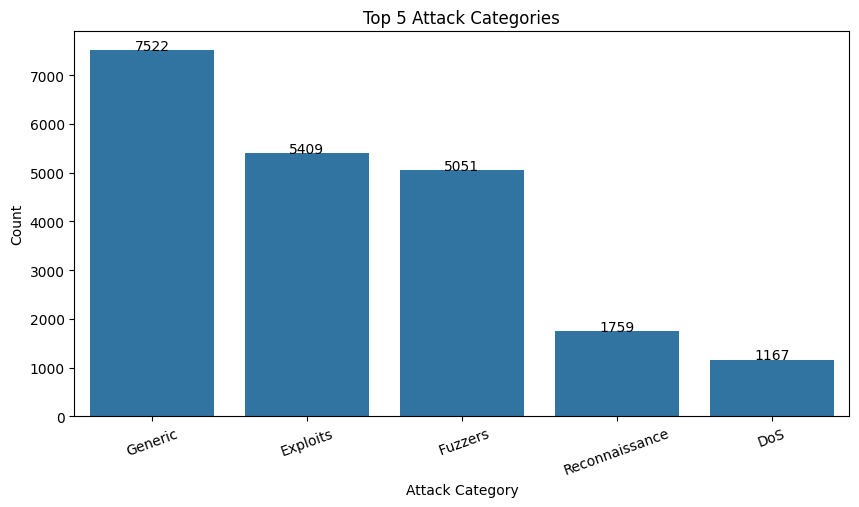

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# BAR CHART
# Top 5 attack categories

top_attacks = df['attack_cat'].value_counts().head(5)

print(top_attacks)
# =====================================
# BAR CHART
# =====================================

plt.figure(figsize=(10,5))

sns.barplot(
   x=top_attacks.index,
     y=top_attacks.values
)

plt.title('Top 5 Attack Categories')
plt.xlabel('Attack Category')
plt.ylabel('Count')

# Labels on bars
for i, value in enumerate(top_attacks.values):
    plt.text(i, value, str(value), ha='center')

plt.xticks(rotation=20)

plt.show()

In [17]:
# =========================
# DEFENDER'S BRIEF
# =========================

brief = """
DEFENDER'S BRIEF

The analysis of the UNSW-NB15 dataset revealed clear differences between normal and attack traffic.
Attack traffic generally showed higher source byte transfers and longer connection durations compared to normal traffic.
These characteristics were used to build a simple detection function that classified network records as either SUSPICIOUS or NORMAL.

The test on 20 random samples showed that rule-based detection can identify several malicious activities with reasonable accuracy.
The most common attack categories included Generic, Exploits, Fuzzers, DoS, and Reconnaissance attacks.

To improve network security, organizations should continuously monitor abnormal traffic patterns such as unusually high byte transfers and long-duration sessions.
Intrusion Detection Systems (IDS) should be updated regularly to detect emerging threats.
Network administrators should also apply traffic filtering, perform regular vulnerability assessments, and educate users on cybersecurity awareness.
Combining automated detection with human monitoring can significantly reduce the risk of successful cyberattacks.
"""

print(brief)


DEFENDER'S BRIEF

The analysis of the UNSW-NB15 dataset revealed clear differences between normal and attack traffic.
Attack traffic generally showed higher source byte transfers and longer connection durations compared to normal traffic.
These characteristics were used to build a simple detection function that classified network records as either SUSPICIOUS or NORMAL.

The test on 20 random samples showed that rule-based detection can identify several malicious activities with reasonable accuracy.
The most common attack categories included Generic, Exploits, Fuzzers, DoS, and Reconnaissance attacks.

To improve network security, organizations should continuously monitor abnormal traffic patterns such as unusually high byte transfers and long-duration sessions.
Intrusion Detection Systems (IDS) should be updated regularly to detect emerging threats.
Network administrators should also apply traffic filtering, perform regular vulnerability assessments, and educate users on cybersecurity